# FID (Fréchet Inception Distance) — 弗雷歇特特征距离

## 从数学公式到代码的完整拆解

FID 是评估图像生成模型（GAN、扩散模型）质量的**核心指标**，值越小说明生成质量越好。

### 本笔记内容
1. 核心思想：把图像质量问题转化为分布距离问题
2. FID 完整公式与每一项的几何意义
3. 用 2D 可视化直观理解分布差异
4. 逐步拆解公式的三个组成部分
5. 完整代码实现（仅用 numpy/scipy）
6. 矩阵平方根：Newton-Schulz 迭代法
7. 灵敏度分析：FID 对什么最敏感


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
from matplotlib import font_manager
from scipy import linalg
import warnings

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# 配置中文字体：优先使用 macOS 内置字体，Linux 备选 Noto/WenQuanYi
_cjk_candidates = ['STHeiti', 'Heiti TC', 'PingFang HK', 'Songti SC', 'Kaiti SC',
                   'Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'SimHei', 'Arial Unicode MS']
_found = None
for _name in _cjk_candidates:
    try:
        font_manager.findfont(_name, fallback_to_default=False)
        _found = _name
        break
    except Exception:
        continue

if _found:
    # CJK 字体处理中文；DejaVu Sans 作为紧随其后的后备，
    # 用于 CJK 字体缺失的字形（如 Unicode 下标 ₁₂、负号等）
    plt.rcParams['font.sans-serif'] = [_found, 'DejaVu Sans'] + plt.rcParams['font.sans-serif']
    print(f'中文字体：{_found}，后备：DejaVu Sans')
else:
    print('未找到中文字体，标题可能显示方块，不影响计算')

plt.rcParams['axes.unicode_minus'] = False   # 负号正常显示

# 过滤"字体回退"警告：CJK 字体遇到下标/特殊符号时 matplotlib 会警告
# 但实际会自动回退到 DejaVu Sans 正确渲染，警告可安全忽略
warnings.filterwarnings('ignore', category=UserWarning,
                        message='Glyph .* missing from font')


中文字体：STHeiti，后备：DejaVu Sans


## 1. 核心思想：图像质量 → 分布距离

**直觉**：好的生成模型应该产生和真实图像"同分布"的图像。
FID 通过比较两组图像的**特征分布**来量化这种差异。

### 计算流程

```
┌─────────────┐   Inception V3    ┌─────────────────┐
│ 真实图像集   │ ──────────────── ▶│ 特征向量集 (n×d) │──▶  N(μ₁, Σ₁)  ──┐
└─────────────┘  提取2048维特征    └─────────────────┘                    │
                                                                         ├──▶  FID
┌─────────────┐   Inception V3    ┌─────────────────┐                    │
│ 生成图像集   │ ──────────────── ▶│ 特征向量集 (m×d) │──▶  N(μ₂, Σ₂)  ──┘
└─────────────┘                   └─────────────────┘
```

**核心假设**：图像特征在高维空间中近似服从**多元高斯分布**。
通过比较两个高斯分布之间的 Fréchet 距离，我们就能量化生成质量。


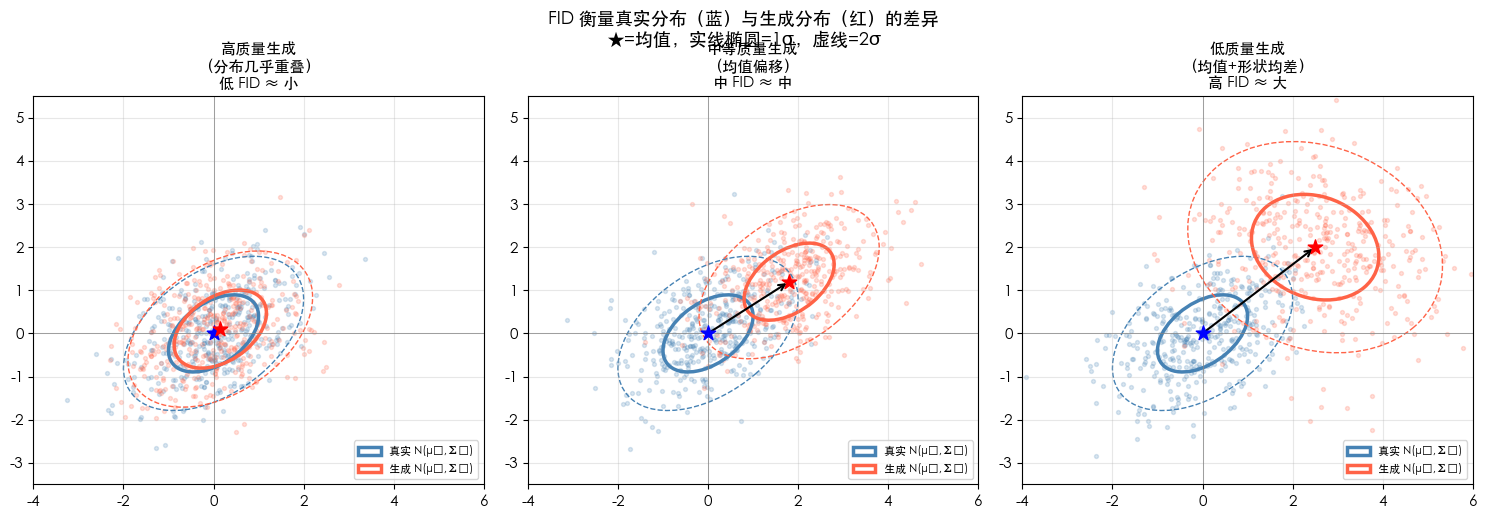

In [8]:
# =================================================================
# 可视化：真实图像 vs 生成图像的特征分布（用2D投影演示）
# =================================================================

def draw_confidence_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """
    绘制二元高斯分布的置信椭圆（等密度线）

    原理：对协方差矩阵做特征分解，得到椭圆的方向和轴长
    n_std：椭圆对应的标准差倍数（1σ≈68%, 2σ≈95%）
    """
    # Pearson 相关系数 = 协方差 / (σx * σy)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    # 用单位圆通过仿射变换得到椭圆
    ell_rx = np.sqrt(1 + pearson)   # x轴半径
    ell_ry = np.sqrt(1 - pearson)   # y轴半径
    ellipse = Ellipse((0, 0), width=ell_rx * 2, height=ell_ry * 2, **kwargs)
    # 缩放（乘以各轴标准差）+ 旋转45度 + 平移到均值处
    t = (transforms.Affine2D()
         .rotate_deg(45)
         .scale(np.sqrt(cov[0, 0]) * n_std, np.sqrt(cov[1, 1]) * n_std)
         .translate(*mean))
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)

# ------------------------------------------------------------
# 三个场景：高/中/低质量生成
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scenarios = [
    {
        'title': '高质量生成\n（分布几乎重叠）',
        'mu1': np.array([0., 0.]),
        'cov1': np.array([[1.0, 0.4], [0.4, 0.8]]),
        'mu2': np.array([0.15, 0.1]),
        'cov2': np.array([[1.05, 0.38], [0.38, 0.82]]),
        'fid': '低 FID ≈ 小',
    },
    {
        'title': '中等质量生成\n（均值偏移）',
        'mu1': np.array([0., 0.]),
        'cov1': np.array([[1.0, 0.4], [0.4, 0.8]]),
        'mu2': np.array([1.8, 1.2]),
        'cov2': np.array([[1.0, 0.4], [0.4, 0.8]]),
        'fid': '中 FID ≈ 中',
    },
    {
        'title': '低质量生成\n（均值+形状均差）',
        'mu1': np.array([0., 0.]),
        'cov1': np.array([[1.0, 0.4], [0.4, 0.8]]),
        'mu2': np.array([2.5, 2.0]),
        'cov2': np.array([[2.0, -0.3], [-0.3, 1.5]]),
        'fid': '高 FID ≈ 大',
    },
]

for ax, s in zip(axes, scenarios):
    pts1 = np.random.multivariate_normal(s['mu1'], s['cov1'], 400)
    pts2 = np.random.multivariate_normal(s['mu2'], s['cov2'], 400)
    ax.scatter(pts1[:, 0], pts1[:, 1], alpha=0.2, c='steelblue', s=8)
    ax.scatter(pts2[:, 0], pts2[:, 1], alpha=0.2, c='tomato', s=8)
    # 1σ 实线，2σ 虚线
    draw_confidence_ellipse(s['mu1'], s['cov1'], ax, n_std=1,
        color='steelblue', fill=False, lw=2.5, label='真实 N(μ₁,Σ₁)')
    draw_confidence_ellipse(s['mu1'], s['cov1'], ax, n_std=2,
        color='steelblue', fill=False, lw=1, linestyle='--')
    draw_confidence_ellipse(s['mu2'], s['cov2'], ax, n_std=1,
        color='tomato', fill=False, lw=2.5, label='生成 N(μ₂,Σ₂)')
    draw_confidence_ellipse(s['mu2'], s['cov2'], ax, n_std=2,
        color='tomato', fill=False, lw=1, linestyle='--')
    # 均值星号
    ax.scatter(*s['mu1'], c='blue', s=120, marker='*', zorder=6)
    ax.scatter(*s['mu2'], c='red',  s=120, marker='*', zorder=6)
    # 均值连线
    ax.annotate('', xy=s['mu2'], xytext=s['mu1'],
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.set_title(f"{s['title']}\n{s['fid']}", fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(-4, 6); ax.set_ylim(-3.5, 5.5)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.suptitle('FID 衡量真实分布（蓝）与生成分布（红）的差异\n'
             '★=均值，实线椭圆=1σ，虚线=2σ', y=1.03, fontsize=13, fontweight='bold')
plt.show()


## 2. FID 完整公式

$$
\boxed{
\text{FID} = \underbrace{\|\mu_1 - \mu_2\|^2}_{\text{① 均值差}} + \underbrace{\text{Tr}(\Sigma_1) + \text{Tr}(\Sigma_2)}_{\text{② 各自散度}} \underbrace{- 2\,\text{Tr}\!\left(\sqrt{\Sigma_1 \Sigma_2}\right)}_{\text{③ 交叉项（奖励相似）}}
}
$$

| 符号 | 含义 | 维度 |
|------|------|------|
| $\mu_1, \mu_2$ | 真实/生成图像特征的**均值向量** | $(d,)$ |
| $\Sigma_1, \Sigma_2$ | 真实/生成图像特征的**协方差矩阵** | $(d \times d)$ |
| $\text{Tr}(A)$ | 矩阵的**迹**（主对角线之和）| 标量 |
| $\sqrt{\Sigma_1 \Sigma_2}$ | 矩阵乘积的**矩阵平方根** | $(d \times d)$ |

**数学背景**：FID 就是两个多元高斯分布之间的 **Wasserstein-2 距离的平方**（也叫 Fréchet 距离）：

$$W_2^2\bigl(\mathcal{N}(\mu_1,\Sigma_1),\, \mathcal{N}(\mu_2,\Sigma_2)\bigr) = \|\mu_1-\mu_2\|^2 + \text{Tr}\!\left(\Sigma_1 + \Sigma_2 - 2(\Sigma_1^{1/2}\Sigma_2\Sigma_1^{1/2})^{1/2}\right)$$


In [ ]:
# =================================================================
# 公式各项的直觉图解
# =================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- ① 均值差：圆心之间的欧氏距离 ----
ax = axes[0]
theta = np.linspace(0, 2*np.pi, 200)

# 真实分布（蓝色圆）
r1 = 1.5; cx1, cy1 = 0, 0
ax.plot(cx1 + r1*np.cos(theta), cy1 + r1*np.sin(theta), 'b-', lw=2.5, label='真实 N(μ₁,Σ₁)')
ax.scatter(cx1, cy1, c='blue', s=100, marker='*', zorder=5)

# 生成分布（红色圆，有偏移）
r2 = 1.5; cx2, cy2 = 2.5, 1.5
ax.plot(cx2 + r2*np.cos(theta), cy2 + r2*np.sin(theta), 'r-', lw=2.5, label='生成 N(μ₂,Σ₂)')
ax.scatter(cx2, cy2, c='red', s=100, marker='*', zorder=5)

# 标注均值连线和距离
ax.annotate('', xy=(cx2, cy2), xytext=(cx1, cy1),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2.5))
mid_x, mid_y = (cx1+cx2)/2, (cy1+cy2)/2
dist = np.sqrt((cx2-cx1)**2 + (cy2-cy1)**2)
ax.text(mid_x+0.1, mid_y+0.3, f'||μ₁-μ₂|| = {dist:.2f}\n项① = {dist**2:.2f}',
        color='purple', fontsize=10, ha='center')
ax.set_title('① 均值差项 $\||μ_1-μ_2\||^2$\n两分布中心之间的平方距离', fontsize=10)
ax.legend(fontsize=9)
ax.set_xlim(-3.5, 5.5); ax.set_ylim(-3, 4.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# ---- ② 迹：分布的总散度 ----
ax = axes[1]
# 宽分布
r_wide = 2.8
ax.plot(r_wide*np.cos(theta), r_wide*np.sin(theta), 'b-', lw=2.5, label='宽分布（大方差）', alpha=0.7)
# 窄分布
r_narrow = 1.0
ax.plot(r_narrow*np.cos(theta), r_narrow*np.sin(theta), 'r-', lw=2.5, label='窄分布（小方差）', alpha=0.7)
# 标注半径（即标准差）
ax.annotate('', xy=(r_wide, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(r_wide/2, 0.3, f'σ={r_wide:.1f}\nTr(Σ)≈{r_wide**2:.1f}', color='blue', ha='center', fontsize=10)
ax.annotate('', xy=(0, r_narrow), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(0.6, r_narrow/2, f'σ={r_narrow:.1f}\nTr(Σ)≈{r_narrow**2:.1f}', color='red', ha='left', fontsize=10)
ax.set_title('② 迹项 $\mathrm{Tr}(\Sigma_1)+\mathrm{Tr}(\Sigma_2)$\n各自的总方差（分布有多散）', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.scatter(0, 0, c='black', s=80, marker='*', zorder=5)

# ---- ③ 交叉项：形状相似度的奖励 ----
ax = axes[2]
# 相同形状的两个分布（重叠度高，交叉项绝对值大）
cov_same = np.array([[2.0, 0.8], [0.8, 1.0]])
draw_confidence_ellipse(np.array([-1.0, 0.]), cov_same, ax, n_std=1.5,
    color='steelblue', fill=True, alpha=0.25, lw=2)
draw_confidence_ellipse(np.array([1.0, 0.]), cov_same, ax, n_std=1.5,
    color='tomato', fill=True, alpha=0.25, lw=2)
ax.text(0, -2.5, '形状相同 → Tr(√(Σ₁Σ₂)) 大\n→ 交叉项 -2Tr(√(Σ₁Σ₂)) 很负\n→ FID 被拉低（奖励）',
        ha='center', fontsize=10, color='green',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.4))
ax.scatter(-1, 0, c='blue', s=100, marker='*', zorder=5)
ax.scatter(1, 0, c='red', s=100, marker='*', zorder=5)
ax.set_title('③ 交叉项 $-2\mathrm{Tr}(\sqrt{\Sigma_1\Sigma_2})$\n形状越相似此项越负，FID越小', fontsize=10)
ax.set_xlim(-4, 4); ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('FID 公式三个项的几何意义', y=1.02, fontsize=13, fontweight='bold')
plt.show()


## 3. 第一项详解：均值差 $\|\mu_1 - \mu_2\|^2$

$$\text{第一项} = \|\mu_1 - \mu_2\|^2 = \sum_{i=1}^{d}(\mu_{1,i} - \mu_{2,i})^2$$

**物理意义**：两个分布**中心位置**的平方欧氏距离。

- 如果生成图像整体偏暗（颜色特征偏移），这一项会很大
- 等价于对**每个特征维度**的均值差取平方再求和


In [ ]:
# =================================================================
# 演示第一项：均值差 ||μ₁ - μ₂||²
# =================================================================

np.random.seed(42)
d = 6       # 用6维特征便于可视化（实际 Inception V3 输出 2048 维）
n = 1000    # 每组1000个样本

# 真实图像特征分布
mu1_true = np.array([1.0, 2.0, -1.0,  0.5,  1.5, -0.5])
Sigma1    = np.diag([0.5, 0.6,  0.4,  0.7,  0.5,  0.6])

# 生成图像特征分布（有均值偏移）
mu2_true = np.array([1.6, 1.4, -0.3,  1.1,  2.2,  0.2])
Sigma2    = np.diag([0.5, 0.6,  0.4,  0.7,  0.5,  0.6])

# 采样
feats_real = np.random.multivariate_normal(mu1_true, Sigma1, n)  # (1000, 6)
feats_gen  = np.random.multivariate_normal(mu2_true, Sigma2, n)  # (1000, 6)

# --------------------------------------------------
# 步骤1：用样本均值估计总体均值
#   feats.mean(axis=0) 对每个特征维度单独求均值
# --------------------------------------------------
mu1_hat = feats_real.mean(axis=0)   # shape: (6,)
mu2_hat = feats_gen.mean(axis=0)    # shape: (6,)

print("真实特征均值 μ₁:", np.round(mu1_hat, 3))
print("生成特征均值 μ₂:", np.round(mu2_hat, 3))
print()

# --------------------------------------------------
# 步骤2：计算差向量，然后求平方范数
# --------------------------------------------------
diff    = mu1_hat - mu2_hat                     # shape: (6,)
per_dim = diff ** 2                             # 每维度的贡献
term1   = np.dot(diff, diff)                    # = sum(diff**2) = ||diff||²
print(f"差向量 (μ₁ - μ₂): {np.round(diff, 3)}")
print(f"每维度 (μ₁ᵢ-μ₂ᵢ)²: {np.round(per_dim, 4)}")
print(f"第一项 ||μ₁-μ₂||² = {per_dim.sum():.4f}（= {term1:.4f}）")

# --------------------------------------------------
# 可视化
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dims = [f'd{i+1}' for i in range(d)]
x = np.arange(d); w = 0.38

# 左图：均值对比
axes[0].bar(x - w/2, mu1_hat, w, label='μ₁ (真实)', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, mu2_hat, w, label='μ₂ (生成)', color='tomato',    alpha=0.85)
# 标注差值
for i, (v1, v2) in enumerate(zip(mu1_hat, mu2_hat)):
    ymax = max(v1, v2) + 0.05
    axes[0].annotate('', xy=(i, v2), xytext=(i, v1),
                     arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
axes[0].set_xticks(x); axes[0].set_xticklabels(dims)
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_title('各维度的均值对比（紫色双箭头=差值）')
axes[0].set_ylabel('均值')

# 右图：每维度的均值差平方
bars = axes[1].bar(dims, per_dim, color='purple', alpha=0.75, edgecolor='black')
for bar, val in zip(bars, per_dim):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.001, f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[1].set_title(f'每维度贡献 (μ₁ᵢ-μ₂ᵢ)²\n总和 = {term1:.4f}（= 第一项）')
axes[1].set_ylabel('(μ₁ᵢ - μ₂ᵢ)²')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print(f"\n第一项 = {' + '.join(f'{v:.4f}' for v in per_dim)} = {term1:.4f}")


## 4. 第二项详解：协方差迹 $\text{Tr}(\Sigma_1) + \text{Tr}(\Sigma_2)$

$$
\text{Tr}(\Sigma) = \sum_{i=1}^{d} \Sigma_{ii} = \text{所有特征维度的方差之和}
$$

**物理意义**：衡量分布的**总散度**（有多"散"）。

- $\Sigma_{ii}$（对角线元素）= 第 $i$ 个特征维度的方差
- $\text{Tr}(\Sigma)$ = 所有维度方差之和 = 分布在特征空间中的总"扩散程度"
- 注意：这一项不单独决定好坏，要结合第三项（交叉项）一起解读

**协方差矩阵的结构**：
- 对角元素 $\Sigma_{ii}$ = 第 $i$ 维的方差（散度）
- 非对角元素 $\Sigma_{ij}$ = 第 $i$、$j$ 维之间的协方差（相关性）
- 迹只用到对角线，体现各维度的独立散度


In [ ]:
# =================================================================
# 演示第二项：协方差矩阵和迹的计算
# =================================================================

# --------------------------------------------------
# 步骤3：计算样本协方差矩阵
#   np.cov 期望输入 shape (d, n)，所以要转置 feats.T
#   输出 shape: (d, d)
# --------------------------------------------------
Sigma1_hat = np.cov(feats_real.T)   # shape: (6, 6)
Sigma2_hat = np.cov(feats_gen.T)    # shape: (6, 6)

print("真实特征协方差矩阵 Σ₁ (6×6):")
print(np.round(Sigma1_hat, 3))
print(f"\nTr(Σ₁) = Σ₁₁+Σ₂₂+…+Σ₆₆ = {np.trace(Sigma1_hat):.4f}")
print(f"对角线（各维方差）: {np.round(np.diag(Sigma1_hat), 4)}")
print()
print(f"Tr(Σ₂) = {np.trace(Sigma2_hat):.4f}")
print(f"\n第二项 = Tr(Σ₁) + Tr(Σ₂) = {np.trace(Sigma1_hat):.4f} + {np.trace(Sigma2_hat):.4f}"
      f" = {np.trace(Sigma1_hat)+np.trace(Sigma2_hat):.4f}")

# --------------------------------------------------
# 可视化：协方差矩阵热力图
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

def plot_cov_heatmap(ax, cov, title):
    vabs = max(abs(cov).max(), 0.01)
    im = ax.imshow(cov, cmap='RdBu_r', vmin=-vabs, vmax=vabs)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(cov.shape[0]):
        for j in range(cov.shape[1]):
            txt_color = 'white' if abs(cov[i,j]) > vabs*0.65 else 'black'
            ax.text(j, i, f'{cov[i,j]:.3f}', ha='center', va='center',
                    color=txt_color, fontsize=9)
    # 黄框高亮对角线（对迹有贡献的元素）
    for i in range(cov.shape[0]):
        ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False,
                                   edgecolor='gold', lw=3.5))
    trace_val = np.trace(cov)
    ax.set_title(f'{title}\nTr = {trace_val:.4f}（金框对角线之和）')
    ax.set_xticks(range(6)); ax.set_yticks(range(6))
    ax.set_xticklabels([f'd{i+1}' for i in range(6)])
    ax.set_yticklabels([f'd{i+1}' for i in range(6)])

plot_cov_heatmap(axes[0], Sigma1_hat, '真实协方差矩阵 Σ₁')
plot_cov_heatmap(axes[1], Sigma2_hat, '生成协方差矩阵 Σ₂')

plt.tight_layout()
plt.show()
print("★ 迹 = 对角线（金框）元素之和 = 各特征维度方差之和 = 分布的总散度")


## 5. 第三项详解：矩阵平方根 $-2\,\text{Tr}\!\left(\sqrt{\Sigma_1 \Sigma_2}\right)$

这是 FID 公式中最复杂但也最关键的项。

### 什么是矩阵平方根？

对于矩阵 $A$，其矩阵平方根 $A^{1/2}$ 满足：$A^{1/2} \cdot A^{1/2} = A$

注意：这**不是**对每个元素开方，而是一种矩阵运算！

### 为什么有交叉项？

类比标量情形：

$$
(a - b)^2 = a^2 + b^2 - 2ab \quad \text{（标量）}
$$

$$
W_2^2 = \|\mu_1-\mu_2\|^2 + \text{Tr}(\Sigma_1) + \text{Tr}(\Sigma_2) - 2\,\text{Tr}(\sqrt{\Sigma_1\Sigma_2})  \quad \text{（矩阵类比）}
$$

$-2ab$ 对应 $-2\,\text{Tr}(\sqrt{\Sigma_1\Sigma_2})$：
- 两个协方差矩阵越**相似**，$\text{Tr}(\sqrt{\Sigma_1\Sigma_2})$ 越大
- 此项越**负** → FID 越小 → 生成质量越好

### 计算方法

- `scipy.linalg.sqrtm`：基于 Schur 分解，适合 CPU 小矩阵
- Newton-Schulz 迭代：只用矩阵乘法，可在 GPU 上加速（见第7节）


In [ ]:
# =================================================================
# 演示第三项：矩阵平方根的计算
# =================================================================

# --------------------------------------------------
# 步骤4：计算矩阵乘积 Σ₁ × Σ₂
#   注意：这是普通矩阵乘法，不是元素乘法
# --------------------------------------------------
cov_product = Sigma1_hat @ Sigma2_hat   # shape: (6, 6)

# --------------------------------------------------
# 步骤5：计算矩阵平方根
#   scipy.linalg.sqrtm 内部用 Schur 分解实现
#   返回的是复数矩阵，取实部（理论上应为实数，虚部是数值误差）
# --------------------------------------------------
sqrt_cov = linalg.sqrtm(cov_product)
sqrt_cov = sqrt_cov.real                # 消除极小的数值误差虚部

print("矩阵乘积 Σ₁ @ Σ₂:")
print(np.round(cov_product, 3))
print()
print("矩阵平方根 √(Σ₁Σ₂):")
print(np.round(sqrt_cov, 3))
print()

# 验证：sqrt^2 应该还原为原矩阵
error = np.abs(sqrt_cov @ sqrt_cov - cov_product).max()
print(f"验证 √(Σ₁Σ₂) @ √(Σ₁Σ₂) ≈ Σ₁Σ₂，最大误差: {error:.2e}")
print()

# --------------------------------------------------
# 步骤6：计算迹和第三项
# --------------------------------------------------
trace_sqrt = np.trace(sqrt_cov)
term3      = -2 * trace_sqrt
print(f"Tr(√(Σ₁Σ₂)) = {trace_sqrt:.4f}")
print(f"第三项 = -2 × {trace_sqrt:.4f} = {term3:.4f}")

# --------------------------------------------------
# 可视化：三个矩阵对比
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

mats = [Sigma1_hat, Sigma2_hat, sqrt_cov]
titles = [
    f'Σ₁（真实协方差）\nTr = {np.trace(Sigma1_hat):.3f}',
    f'Σ₂（生成协方差）\nTr = {np.trace(Sigma2_hat):.3f}',
    f'√(Σ₁Σ₂)  ← FID用这个的迹\nTr = {trace_sqrt:.3f}',
]
highlights = [False, False, True]

for ax, mat, title, hl in zip(axes, mats, titles, highlights):
    vabs = max(abs(mat).max(), 0.01)
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-vabs, vmax=vabs)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            txt_color = 'white' if abs(mat[i,j]) > vabs*0.65 else 'black'
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    color=txt_color, fontsize=8.5)
    for i in range(mat.shape[0]):
        c = 'gold' if not hl else 'lime'
        ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False,
                                   edgecolor=c, lw=3.5))
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(6)); ax.set_yticks(range(6))
    ax.set_xticklabels([f'd{i+1}' for i in range(6)])
    ax.set_yticklabels([f'd{i+1}' for i in range(6)])

axes[2].set_title(f'√(Σ₁Σ₂)  ← FID用这个的迹\nTr = {trace_sqrt:.3f}  ★绿框=对角线', fontsize=10)
plt.tight_layout()
plt.show()


## 6. 汇总：完整 FID 计算函数

$$
\text{FID} = \underbrace{\|\mu_1 - \mu_2\|^2}_{\text{第一项}} + \underbrace{\text{Tr}(\Sigma_1) + \text{Tr}(\Sigma_2)}_{\text{第二项}} + \underbrace{(-2\,\text{Tr}\!\left(\sqrt{\Sigma_1 \Sigma_2}\right))}_{\text{第三项（负值）}}
$$


In [ ]:
# =================================================================
# 完整 FID 计算函数（含逐步拆解）
# =================================================================

def calc_fid(feats1, feats2, verbose=True):
    """
    计算两组特征向量之间的 FID 分数

    参数：
        feats1: shape (n1, d)  真实图像特征矩阵
        feats2: shape (n2, d)  生成图像特征矩阵
        verbose: 是否打印各项中间结果
    返回：
        fid: 标量 FID 分数（越小越好）
    """
    # ---- 步骤1：计算样本均值 ----
    # 对每个特征维度独立求均值，得到 d 维均值向量
    mu1 = feats1.mean(axis=0)           # shape: (d,)
    mu2 = feats2.mean(axis=0)           # shape: (d,)

    # ---- 步骤2：计算样本协方差矩阵 ----
    # np.cov 期望 shape (d, n)，需要转置
    # 结果是无偏估计（除以 n-1）
    sigma1 = np.cov(feats1.T)           # shape: (d, d)
    sigma2 = np.cov(feats2.T)           # shape: (d, d)

    # ---- 步骤3：均值差项 ----
    diff   = mu1 - mu2
    term1  = np.dot(diff, diff)         # ||μ₁ - μ₂||²

    # ---- 步骤4：协方差迹项 ----
    term2  = np.trace(sigma1) + np.trace(sigma2)

    # ---- 步骤5：矩阵平方根项 ----
    # scipy.linalg.sqrtm 用 Schur 分解计算矩阵平方根
    # 对实对称正半定矩阵结果应为实矩阵，.real 去除数值误差虚部
    sqrt_cov = linalg.sqrtm(sigma1 @ sigma2).real
    term3    = -2 * np.trace(sqrt_cov)

    # ---- 步骤6：汇总 ----
    fid = term1 + term2 + term3

    if verbose:
        print(f"  第一项  ||μ₁-μ₂||²          = {term1:>10.4f}  （均值差，越大越差）")
        print(f"  第二项  Tr(Σ₁)+Tr(Σ₂)        = {term2:>10.4f}  （散度之和）")
        print(f"  第三项  -2Tr(√(Σ₁Σ₂))       = {term3:>10.4f}  （交叉项，越负越好）")
        print(f"  {'─'*52}")
        print(f"  FID = {term1:.4f} + {term2:.4f} + ({term3:.4f}) = {fid:.4f}")
    return fid


print("=" * 56)
print("示例：6 维特征，n=1000 样本")
print("=" * 56)
fid_val = calc_fid(feats_real, feats_gen)
print(f"\n  ✓ FID = {fid_val:.4f}")


## 7. 矩阵平方根：Newton-Schulz 迭代法

`scipy.linalg.sqrtm` 对 CPU 上的小矩阵够用，但对于大矩阵（如 Inception V3 的 2048×2048）
或需要在 **GPU** 上运行时，可以用 **Newton-Schulz 迭代法**（只依赖矩阵乘法）。

### 算法

**初始化**：

$$Y_0 = \frac{A}{\|A\|_F}, \quad Z_0 = I$$

**迭代**（收敛很快，通常 20-50 次）：

$$T_k = \frac{1}{2}\left(3I - Z_k Y_k\right)$$
$$Y_{k+1} = Y_k T_k, \quad Z_{k+1} = T_k Z_k$$

**结果**：$Y_k \cdot \sqrt{\|A\|_F} \approx A^{1/2}$

**直觉**：类似于求数值平方根的 Newton 法 $x_{n+1} = \frac{1}{2}\left(x_n + \frac{a}{x_n}\right)$，
但推广到矩阵域，利用 $Z$ 跟踪逆矩阵使迭代数值稳定。


In [ ]:
# =================================================================
# Newton-Schulz 迭代法计算矩阵平方根
# =================================================================

def sqrtm_newton_schulz(A, num_iters=100, tol=1e-6):
    """
    用 Newton-Schulz 迭代法计算正半定矩阵 A 的平方根

    优点：只用矩阵乘法，可以在 GPU (PyTorch/JAX) 上加速运行
    局限：对病态矩阵（特征值差异极大）可能需要更多迭代

    算法：
        Y₀ = A / ||A||F          # 归一化
        Z₀ = I                   # 辅助矩阵（跟踪逆）
        T  = (3I - Z @ Y) / 2   # 迭代步
        Y  = Y @ T
        Z  = T @ Z
        结果 = Y * sqrt(||A||F)  # 还原缩放
    """
    A_norm = np.linalg.norm(A, 'fro')   # Frobenius 范数，用于归一化避免数值溢出
    Y = A / A_norm                       # 归一化矩阵
    n = A.shape[0]
    I = np.eye(n)
    Z = np.eye(n)

    errors = []
    for i in range(num_iters):
        T = (3 * I - Z @ Y) / 2         # Newton-Schulz 核心迭代步
        Y = Y @ T
        Z = T @ Z

        result = Y * np.sqrt(A_norm)    # 还原缩放得到当前近似平方根
        # 误差 = ||A - result²||F / ||A||F
        error = np.linalg.norm(A - result @ result, 'fro') / A_norm
        errors.append(error)

        if error <= tol:
            print(f"  Newton-Schulz 收敛于第 {i+1} 次迭代，误差: {error:.2e}")
            return result, errors

    print(f"  达到最大迭代 {num_iters} 次，最终误差: {errors[-1]:.2e}")
    return result, errors


# --------------------------------------------------
# 在一个正定矩阵上测试
# --------------------------------------------------
np.random.seed(1)
B = np.random.randn(8, 8)
A_pd = B @ B.T + np.eye(8) * 0.5   # 构造正定矩阵

print("测试 Newton-Schulz 矩阵平方根（8×8 正定矩阵）:")
sqrt_ns, errs = sqrtm_newton_schulz(A_pd)
sqrt_sp = linalg.sqrtm(A_pd).real

print(f"  scipy vs NS 最大差异: {np.abs(sqrt_ns - sqrt_sp).max():.2e}")
print(f"  验证 √A @ √A ≈ A 的最大误差: {np.abs(sqrt_ns @ sqrt_ns - A_pd).max():.2e}")

# --------------------------------------------------
# 绘制收敛曲线
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

iters = range(1, len(errs)+1)
axes[0].semilogy(iters, errs, 'o-', color='green', lw=2, ms=5)
axes[0].axhline(1e-6, color='red', linestyle='--', label='收敛阈值 1e-6')
axes[0].set_xlabel('迭代次数'); axes[0].set_ylabel('相对误差（对数轴）')
axes[0].set_title('Newton-Schulz 迭代收敛曲线\n（通常 20~50 步可达机器精度）')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
# 标注收敛轮次
conv_iter = next((i for i, e in enumerate(errs) if e <= 1e-6), len(errs)-1) + 1
axes[0].axvline(conv_iter, color='orange', linestyle=':', alpha=0.8)
axes[0].text(conv_iter+0.3, errs[0]*0.3, f'第{conv_iter}轮收敛', color='orange', fontsize=10)

# 对比 scipy vs NS 的差异热力图
diff_mat = np.abs(sqrt_ns - sqrt_sp)
im = axes[1].imshow(diff_mat, cmap='Blues')
plt.colorbar(im, ax=axes[1])
axes[1].set_title(f'|Newton-Schulz 结果 - scipy 结果|\n最大差异: {diff_mat.max():.2e}（数值误差极小）')

plt.tight_layout()
plt.show()


## 8. 灵敏度分析：FID 对什么最敏感？

让我们通过实验来验证 FID 如何响应三类常见的生成质量问题：

| 问题类型 | 现象 | FID 响应 |
|---------|------|---------|
| **均值偏移** | 生成图像颜色整体偏暗/偏亮 | 第一项增大，二次增长 |
| **多样性不足** | 模式崩塌，生成图像缺乏多样性 | 方差缩小，FID增大 |
| **样本数量不足** | 用太少图像计算 FID | 估计不稳定，FID虚高 |


In [ ]:
# =================================================================
# FID 灵敏度实验
# =================================================================

def fid_fast(f1, f2):
    """快速计算 FID（无打印），用于批量实验"""
    mu1, mu2 = f1.mean(0), f2.mean(0)
    s1, s2   = np.cov(f1.T), np.cov(f2.T)
    diff     = mu1 - mu2
    t1 = np.dot(diff, diff)
    t2 = np.trace(s1) + np.trace(s2)
    t3 = -2 * np.trace(linalg.sqrtm(s1 @ s2).real)
    return t1 + t2 + t3

np.random.seed(42)
d  = 32     # 适中维度，计算更快但仍有代表性
n  = 1000   # 基准样本数

# 真实特征：标准正态
mu_real   = np.zeros(d)
cov_real  = np.eye(d)
f_real = np.random.multivariate_normal(mu_real, cov_real, n)

# --------------------------------------------------
# 实验1：均值偏移（模拟色彩/亮度系统性偏差）
# --------------------------------------------------
shifts = np.linspace(0, 3.0, 20)
fid_shifts = []
for s in shifts:
    f_gen = np.random.multivariate_normal(mu_real + s, cov_real, n)
    fid_shifts.append(fid_fast(f_real, f_gen))

# --------------------------------------------------
# 实验2：方差缩放（模拟多样性问题）
# --------------------------------------------------
scales = np.linspace(0.1, 4.0, 30)
fid_scales = []
for sc in scales:
    f_gen = np.random.multivariate_normal(mu_real, cov_real * sc, n)
    fid_scales.append(fid_fast(f_real, f_gen))

# --------------------------------------------------
# 实验3：样本数量的影响（同分布时 FID 应趋向 0）
# --------------------------------------------------
ns_list = [50, 100, 200, 500, 1000, 2000, 5000, 10000]
fid_ns  = []
for ns in ns_list:
    f_gen = np.random.multivariate_normal(mu_real, cov_real, ns)
    fid_ns.append(fid_fast(f_real, f_gen))

# --------------------------------------------------
# 绘图
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 实验1
axes[0].plot(shifts, fid_shifts, 'o-', color='steelblue', lw=2, ms=5)
# 叠加理论曲线（第一项 = d * shift² 的期望值）
theo1 = [d * s**2 for s in shifts]
axes[0].plot(shifts, theo1, '--', color='gray', lw=1.5, label='理论第一项 d·shift²')
axes[0].set_xlabel('均值偏移量（每维度）')
axes[0].set_ylabel('FID')
axes[0].set_title('实验1：均值偏移的影响（模拟生成图像系统性色偏）')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[0].fill_between(shifts, fid_shifts, alpha=0.15, color='steelblue')

# 实验2
axes[1].plot(scales, fid_scales, 'o-', color='tomato', lw=2, ms=5)
axes[1].axvline(1.0, color='green', linestyle='--', lw=2, label='完美匹配（scale=1.0）')
min_idx = np.argmin(fid_scales)
axes[1].scatter(scales[min_idx], fid_scales[min_idx], s=120, c='green', zorder=5)
axes[1].set_xlabel('方差缩放系数')
axes[1].set_ylabel('FID')
axes[1].set_title('实验2：方差（多样性）的影响（偏高或偏低都会增大 FID）')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
axes[1].annotate('多样性不足(scale<1)', xy=(0.3, fid_scales[3]),
                 xytext=(0.8, max(fid_scales)*0.75),
                 arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
axes[1].annotate('过度多样(scale>1)', xy=(3.0, fid_scales[-8]),
                 xytext=(2.5, max(fid_scales)*0.5),
                 arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

# 实验3
axes[2].semilogx(ns_list, fid_ns, 'o-', color='purple', lw=2, ms=7)
axes[2].axhline(0, color='black', linestyle='--', alpha=0.4, label='理论值（同分布）= 0')
axes[2].set_xlabel('样本数量（对数轴）')
axes[2].set_ylabel('FID')
axes[2].set_title('实验3：样本数量的影响（同分布，FID 应随 n 趋向 0）')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)
axes[2].fill_between(ns_list, fid_ns, alpha=0.15, color='purple')
# 标注阈值
axes[2].axvline(5000, color='red', linestyle=':', lw=1.5, alpha=0.7)
axes[2].text(5500, max(fid_ns)*0.7, '建议\n≥5000', color='red', fontsize=9)

plt.tight_layout()
plt.suptitle('FID 灵敏度分析', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("\n★ 关键结论：")
print("  1. 均值偏移：FID 近似二次增长（因为第一项是平方范数）")
print("  2. 方差偏差：scale=1 时 FID 最小，过高或过低多样性均使 FID 上升")
print("  3. 样本数量：n < 1000 时估计严重偏高，实践中推荐 ≥ 5000 张图像")


In [ ]:
# =================================================================
# 各组成部分的贡献分析（堆叠条形图）
# =================================================================

def fid_breakdown(f1, f2, label=''):
    """计算 FID 并返回各项分解"""
    mu1, mu2 = f1.mean(0), f2.mean(0)
    s1, s2   = np.cov(f1.T), np.cov(f2.T)
    diff = mu1 - mu2
    t1 = np.dot(diff, diff)
    t2 = np.trace(s1) + np.trace(s2)
    t3 = -2 * np.trace(linalg.sqrtm(s1 @ s2).real)
    return {'场景': label, '①均值差': t1, '②迹之和': t2, '③交叉项': t3, 'FID': t1+t2+t3}

np.random.seed(42)
d, n = 32, 800

mu0  = np.zeros(d)
cov0 = np.eye(d)
f0   = np.random.multivariate_normal(mu0, cov0, n)

场景 = [
    ('高质量生成',     np.random.multivariate_normal(mu0 + 0.05, cov0 * 1.05, n)),
    ('均值偏移',       np.random.multivariate_normal(mu0 + 1.0,  cov0,        n)),
    ('多样性不足',     np.random.multivariate_normal(mu0,        cov0 * 0.25, n)),
    ('生成过于多样',   np.random.multivariate_normal(mu0,        cov0 * 3.0,  n)),
    ('均值+方差均差',  np.random.multivariate_normal(mu0 + 1.5,  cov0 * 2.0,  n)),
]

results = [fid_breakdown(f0, f_gen, lbl) for lbl, f_gen in 场景]

labels  = [r['场景']   for r in results]
t1_vals = [r['①均值差'] for r in results]
t2_vals = [r['②迹之和'] for r in results]
t3_vals = [r['③交叉项'] for r in results]
fid_vals= [r['FID']    for r in results]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(labels))

# 左图：堆叠条形图（t3 是负值，从 t1+t2 向下）
bot1 = np.zeros(len(labels))
bot2 = np.array(t1_vals)
bot3 = np.array(t1_vals) + np.array(t2_vals)

b1 = axes[0].bar(x, t1_vals, color='steelblue', label='① 均值差 ||μ₁-μ₂||²')
b2 = axes[0].bar(x, t2_vals, bottom=t1_vals,    color='orange',   label='② 迹之和 Tr(Σ₁)+Tr(Σ₂)')
b3 = axes[0].bar(x, t3_vals, bottom=bot3,        color='green', alpha=0.85, label='③ 交叉项 -2Tr(√(Σ₁Σ₂))')

# 标注 FID 总值
for i, fid in enumerate(fid_vals):
    axes[0].text(i, fid + max(fid_vals)*0.018, f'FID{fid:.0f}',
                 ha='center', fontsize=9, fontweight='bold', color='black')

axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
axes[0].set_title('FID 各项贡献分解（绿色交叉项为负数，可降低FID）')
axes[0].set_ylabel('数值'); axes[0].legend(loc='upper left', fontsize=9)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].grid(True, alpha=0.3, axis='y')

# 右图：FID 总值
colors = ['#2ecc71' if f < 20 else ('#f39c12' if f < 100 else '#e74c3c') for f in fid_vals]
bars = axes[1].bar(labels, fid_vals, color=colors, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, fid_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(fid_vals)*0.01,
                 f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].set_title('各场景 FID 总值（绿色<20 优秀，橙色<100 中等，红色较差）')
axes[1].set_ylabel('FID'); axes[1].set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('FID 各组成项贡献分析', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print("\n各场景 FID 明细：")
print(f"{'场景':<14} {'①均值差':>8} {'②迹之和':>8} {'③交叉项':>10}  {'FID':>8}")
print("─" * 55)
for r in results:
    print(f"{r['场景']:<14} {r['①均值差']:>8.1f} {r['②迹之和']:>8.1f} {r['③交叉项']:>10.1f}  {r['FID']:>8.1f}")


## 9. 完整总结

### FID 公式

$$
\text{FID} = \|\mu_1 - \mu_2\|^2 + \text{Tr}(\Sigma_1) + \text{Tr}(\Sigma_2) - 2\,\text{Tr}\!\left(\sqrt{\Sigma_1 \Sigma_2}\right)
$$

### 七步计算流程

| 步骤 | 操作 | 代码 | 意义 |
|------|------|------|------|
| 1 | 提取特征向量 | `model(imgs)` | 将图像映射到有意义的高维空间 |
| 2 | 计算均值 | `feats.mean(0)` | 估计分布中心 |
| 3 | 计算协方差 | `np.cov(feats.T)` | 估计分布形状 |
| 4 | 均值差项 | `np.dot(mu1-mu2, mu1-mu2)` | 系统性偏差的惩罚 |
| 5 | 迹之和 | `np.trace(s1) + np.trace(s2)` | 两分布各自的总散度 |
| 6 | 矩阵平方根 | `linalg.sqrtm(s1 @ s2).real` | 协方差的"几何均值" |
| 7 | 交叉项 | `-2 * np.trace(sqrt_cov)` | 奖励分布形状相似 |

### 实践建议

- **样本量**：至少 **5000 张图像**，最好 50000+，否则 FID 估计偏高
- **特征提取**：标准做法是用 Inception V3 的池化层输出（2048 维），使不同论文可以横向比较
- **矩阵运算**：2048×2048 的矩阵平方根用 `scipy.linalg.sqrtm` 约需数秒，可用 Newton-Schulz 迭代在 GPU 上加速
- **FID vs KID**：KID（Kernel Inception Distance）用 MMD 代替高斯假设，对小样本更鲁棒，但理解起来更复杂
- **FID 的局限性**：FID 无法区分**多样性**和**保真度**之间的权衡，也不能检测单个样本的质量，只反映整体分布差距

### 参考 FID 范围（仅供大致参考）

| FID | 质量 |
|-----|------|
| < 10 | 优秀（接近真实图像分布） |
| 10 ~ 50 | 良好 |
| 50 ~ 200 | 一般 |
| > 200 | 较差 |
